## **Multi-Class Classification**

We have more than 2 levels (labels). They are mutually exclusive. We use the categorical cross-entropy cost function for the gradient descent algorithm.

**Categorical cross-entropy loss**

The formula is:

$$-\sum y_k log(\hat{p}_k)  $$

In [2]:
import numpy as np
import pandas as pd

## suppose we have y_k = {dog, cat, bird}
## obs 1 - Cat
y = np.array([0,    1,    0])
p = np.array([0.15, 0.75, 0.1]) ## assuming softmax has been used

## categorical cross-entropy loss
## -(0*np.log(0.05) + 1*np.log(0.90) + 0*np.log(0.05))

## categorical cross-entropy loss
np.sum(-y*np.log(p))

np.float64(0.2876820724517809)

In [3]:
## cost function (average)
def categorical_cross_entropy_cost(y, p): ## assuming y and p are matrices
  -np.mean(np.sum(y*np.log(p), axis=1))

## **Example**

Let's predict the account status of customers. We are interested in customers at-risk of leaving the company

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/martinwg/ISA630/refs/heads/master/data/customer_health.csv')
df.head()

,Monthly_Active_Usage_Hours,Support_Tickets_Open,License_Utilization_Rate,Last_Login_Days_Ago,Contract_Type,Account_Status
0,74.908024,1,0.240685,40,Monthly,At-Risk
1,190.142861,6,0.764156,9,Annual,At-Risk
2,146.398788,1,0.424427,57,Monthly,Inactive
3,119.731697,2,0.704144,16,Annual,Stable
4,31.203728,2,0.343580,16,Multi-year,Stable


In [5]:
## get X matrix and y vector
X = df.drop('Account_Status', axis=1)
y = df['Account_Status']

In [6]:
## dummy encode categorical predictors
X = pd.get_dummies(X, drop_first=True)
X.head()

,Monthly_Active_Usage_Hours,Support_Tickets_Open,License_Utilization_Rate,Last_Login_Days_Ago,Contract_Type_Monthly,Contract_Type_Multi-year
0,74.908024,1,0.240685,40,True,False
1,190.142861,6,0.764156,9,False,False
2,146.398788,1,0.424427,57,True,False
3,119.731697,2,0.704144,16,False,False
4,31.203728,2,0.343580,16,False,True


In [7]:
y.value_counts()

,count
Account_Status,
Stable,547
Inactive,251
At-Risk,182
Expansion-Ready,20


In [8]:
## on the background
## most common - one-hot encoding
#### dummy-encoding drops one-level
#### one-hot encoding -  a dummy is created for each level
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()

y_onehot = ohe.fit_transform(y.values.reshape(-1,1))
y_onehot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1000 stored elements and shape (1000, 4)>

In [9]:
## change to dense
y_onehot = y_onehot.toarray()
y_onehot

## this is is what gets used on the background
## if you use sklearn RandomForest
#### rf.fit(X, y)  ## in the background y is converted y_onehot

array([[1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.]])

In [10]:
## y variable
y.value_counts()

,count
Account_Status,
Stable,547
Inactive,251
At-Risk,182
Expansion-Ready,20


In [11]:
## Logistic Regression
#### LR is a binary classification algorithm (not meant for multi-class)
#### the output is p = (0,1)
#### One vs the Rest (OvR)
#### 4 models, e.g., (Stable vs NOT stable) - (Inactive vs Not Inactive) - etc


from sklearn.linear_model import LogisticRegression

## instance
lr = LogisticRegression(solver = 'newton-cg', max_iter = 1000)

## fit on y - y gets converted to y_onehot on the background
lr.fit(X, y)

LogisticRegression(max_iter=1000, solver='newton-cg')

In [15]:
np.round(lr.predict_proba(X),3)

array([[0.417, 0.   , 0.313, 0.271],
       [0.024, 0.346, 0.   , 0.63 ],
       [0.008, 0.   , 0.961, 0.031],
       ...,
       [0.002, 0.   , 0.036, 0.962],
       [0.038, 0.171, 0.001, 0.789],
       [0.548, 0.001, 0.   , 0.452]])

In [17]:
np.sum([0.417, 0.   , 0.313, 0.271])

np.float64(1.001)

In [18]:
## 4 OvR models were fit
## to make the sum 1, a softmax function was used

In [19]:
## y - (sorted alphabetically)
## At-risk
## y1 = {At risk, Not At-Risk}

In [20]:
np.round(lr.coef_, 3)

array([[-0.011,  0.221, -7.021, -0.057,  0.214,  0.349],
       [ 0.037, -0.009,  4.67 , -0.069,  0.04 , -0.317],
       [-0.016, -0.133,  0.163,  0.183, -0.186, -0.106],
       [-0.01 , -0.079,  2.188, -0.057, -0.068,  0.073]])

In [22]:
## multi-class schemes
#### OvR - One vs Rest (most common)
#### OvO - One vs One (more computations, but differentiates better)

from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier

## instance OneVsOneClassifier with logistic regression
ovo = OneVsOneClassifier(LogisticRegression(solver = 'newton-cg', max_iter = 1000))

## fit
ovo.fit(X, y)

OneVsOneClassifier(estimator=LogisticRegression(max_iter=1000,
                                                solver='newton-cg'))

In [23]:
## predictions
yhat = ovo.predict(X)

In [24]:
yhat

array(['Inactive', 'Stable', 'Inactive', 'Stable', 'Stable', 'At-Risk',
       'Stable', 'Inactive', 'Stable', 'Stable', 'Stable', 'Stable',
       'Stable', 'Stable', 'Stable', 'Stable', 'Stable', 'Stable',
       'Inactive', 'Stable', 'Stable', 'Stable', 'Stable', 'Stable',
       'Stable', 'Stable', 'Stable', 'Stable', 'At-Risk', 'Stable',
       'Inactive', 'Stable', 'Inactive', 'Stable', 'At-Risk', 'Stable',
       'At-Risk', 'Inactive', 'At-Risk', 'Inactive', 'Inactive', 'Stable',
       'Stable', 'At-Risk', 'Stable', 'Inactive', 'Stable', 'Stable',
       'Stable', 'Inactive', 'Stable', 'Stable', 'Inactive', 'Inactive',
       'Inactive', 'Stable', 'Stable', 'Stable', 'Inactive', 'Inactive',
       'Stable', 'Stable', 'At-Risk', 'Stable', 'Stable', 'Stable',
       'Stable', 'Stable', 'Stable', 'At-Risk', 'At-Risk', 'Inactive',
       'At-Risk', 'Stable', 'Stable', 'Stable', 'Inactive', 'Inactive',
       'Stable', 'Stable', 'Inactive', 'Inactive', 'Stable', 'Stable',
       'In

In [26]:
## probability
#### decision function
#### softmax is applied to each obs
phat = ovo.decision_function(X) ## log-odds
phat

array([[ 2.28426507, -0.32005848,  3.30323909,  1.29726048],
       [ 2.16132904,  1.30707825, -0.32045072,  3.30815858],
       [ 0.76747179, -0.31304104,  3.31232034,  2.24720321],
       ...,
       [ 0.7374473 , -0.31967371,  2.30335937,  3.31480601],
       [ 0.8131469 ,  2.29238842, -0.31426478,  3.30463577],
       [ 3.3035136 ,  0.69682746, -0.31180906,  2.31163193]])

In [27]:
#### sofmax
phat1 = np.array([ 2.28426507, -0.32005848,  3.30323909,  1.29726048])
np.exp(phat1)/np.sum(np.exp(phat1))

array([0.23713566, 0.01753693, 0.656949  , 0.08837842])

In [28]:
#### the prediction is the highest probability
###### doesn't mean an observation has to have a prob > 0.5 to be assigned a given level
[0.25, 0.24, 0.26 , 0.25]

[0.25, 0.24, 0.26, 0.25]

**Metrics**

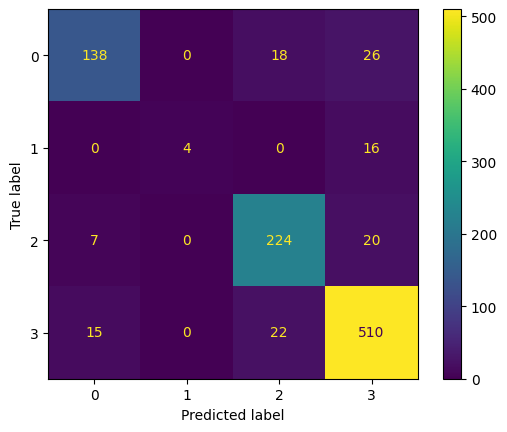

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(confusion_matrix(y, yhat)).plot()

In [32]:
## accuracy
from sklearn.metrics import accuracy_score

accuracy_score(y, yhat)

0.876

In [37]:
## recall (detection rate, sensitivity)
from sklearn.metrics import recall_score

recall_score(y, yhat, average = "macro")

0.6957575888062351

### **Fit a Tensorflow NN**

In [38]:
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Sequential

In [42]:
## Sequential
nn = Sequential()
## Input layer
nn.add(Input(shape = (X.shape[1],)))
## Hidden layer
nn.add(Dense(20, activation = 'relu'))
## Regularize
nn.add(Dropout(0.2))
## Hidden layer
nn.add(Dense(10, activation = 'relu'))
## Regularize
nn.add(Dropout(0.2))
## Output layer
nn.add(Dense(4, activation = 'softmax'))  ## neurons = #levels of y, activation: softmax

In [45]:
## Compile
#### Cost (loss): categorical_crossentropy (requires a onehot y vawriable)
#### Cost (loss): sparse_categorical_crossentropy (requires a y = {0,1,2,3})
#### optimizer: Adam
nn.compile(loss = 'categorical_crossentropy', optimizer = 'adam')

In [46]:
## fit
#### X, y
#### epochs: full rounds on the whole dataset
#### batch_size: 32
#### validation_data (we dont have X_val, y_val)
#### validation_split = 0.1
nn.fit(X, y_onehot, epochs = 100, batch_size = 32, validation_split = 0.1)

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.9165 - val_loss: 0.9008
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9487 - val_loss: 0.9035
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9929 - val_loss: 0.9011
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9403 - val_loss: 0.9010
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9698 - val_loss: 0.9007
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9244 - val_loss: 0.8969
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9183 - val_loss: 0.8910
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8955 - val_loss: 0.8900
Epoch 9/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9440 - val_loss: 0.8844
Epoch 10/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8803 - val_loss: 0.8896
Epoch 11/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9191 - val_loss: 0.8831
Epoch 12/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.

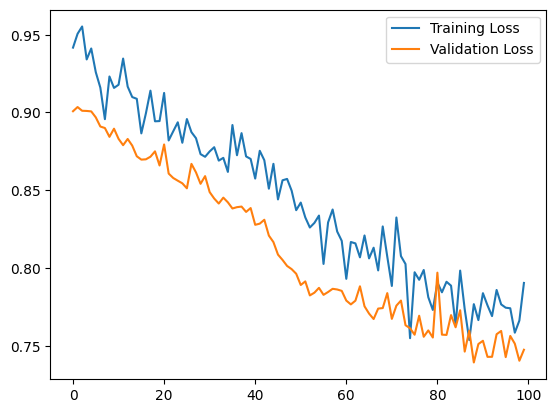

In [48]:
## Learning Curve
#### Training Loss
#### Validation Loss

plt.plot(nn.history.history['loss'], label = 'Training Loss')
plt.plot(nn.history.history['val_loss'], label = 'Validation Loss')
plt.legend()
plt.show()

In [51]:
## How to predict a multiclass problem
#### np.argmax(nn.predict(X), axis = 1) = {0,1,2,3}
yhat = np.argmax(nn.predict(X), axis = 1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [52]:
yhat

array([2, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 3, 3, 3, 3, 2, 3, 2, 2, 3, 3, 3,
       3, 2, 3, 3, 3, 3, 3, 3, 3, 2, 2, 3, 3, 3, 2, 2, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 2, 2, 3, 3, 3, 2, 2, 3, 3, 2, 2, 3, 3, 3, 3, 2, 3,
       3, 2, 3, 3, 2, 3, 3, 3, 2, 3, 2, 3, 2, 2, 3, 3, 3, 3, 3, 3, 2, 2,
       2, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2,
       3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 3, 3, 3, 2, 2, 3, 3, 3, 3, 3, 3, 2,
       3, 3, 3, 2, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 2, 3, 2, 2, 3, 3, 3, 3,
       3, 2, 2, 3, 3, 2, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 2, 2, 2, 3, 3,
       3, 2, 3, 3, 3, 3, 3, 2, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3,
       2, 3, 3, 3, 3, 2, 3, 2, 2, 3, 2, 3, 3, 2, 3, 2, 3, 2, 3, 3, 3, 3,
       3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 2, 3, 3, 3, 3, 3, 2, 3,
       3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 3,
       2, 3, 3, 3, 2, 3, 3, 3, 3, 2, 3, 2, 3, 3, 3,

## **Multi-Label Classification**

In this problem y labels can be assigned repeatedly to one of more observations, so y is not mutually exclusive. The most common technique to use is called binary relevance: fitting a model to each the classes independently and getting propensities without requiring they sum to 1.

* sklearn: **some models** have multilabel implemented, e.g., RF (probability[p] for each class - output will be a 1 if p > 0.5).
* tensorflow: loss: binary_crossentropy and the output (sigmoid activation) - then the prediction will 1 if p[given class] > 0.5 (threshold).

In [53]:
import pandas as pd
import numpy as np

df = pd.read_csv('https://raw.githubusercontent.com/martinwg/ISA630/refs/heads/master/data/moderation_dataset.csv')
df.head()

,id,comment_text,toxic,threat,pii_leak,harassment,urgent
0,1001,"If I don't get my refund by Friday, I'm coming...",1,1,0,0,1
1,1002,"The support agent, Michael Thompson, is a brai...",1,0,0,1,0
2,1003,My account is hacked! My email is waldyn.m@exa...,0,0,1,0,1
3,1004,I am so happy with the service! The team was v...,0,0,0,0,0
4,1005,You people are pathetic. I hope your office bu...,1,1,0,0,0


In [54]:
## TF-IDF vectorizer for comment_text (X)
from sklearn.feature_extraction.text import TfidfVectorizer

## instance
vectorizer = TfidfVectorizer() ## stop_words = "english"

## fit and transform
X = vectorizer.fit_transform(df['comment_text'])

In [56]:
X = X.toarray()

In [59]:
## pd.DataFrame
pd.DataFrame(X, columns = vectorizer.get_feature_names_out())

,00,021000021,1000,112,123,1985,1999,20,22,400,...,why,will,window,with,wonderful,work,worst,wrote,you,your
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.119395,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.207501,0.0,0.255409,0.0,0.0,0.000000,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.215229,0.0,0.000000,0.0,0.0,0.000000,0.000000
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.232237,0.0,0.000000,0.0,0.0,0.292654,0.148362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.316949,0.000000
106,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000
107,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000
108,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.315488,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.213758


In [60]:
X.shape

(110, 504)

In [61]:
y = df.drop(['id', 'comment_text'], axis = 1)

In [62]:
## y is one-hot encoded matrix
y

,toxic,threat,pii_leak,harassment,urgent
0,1,1,0,0,1
1,1,0,0,1,0
2,0,0,1,0,1
3,0,0,0,0,0
4,1,1,0,0,0
...,...,...,...,...,...
105,1,0,0,0,0
106,0,0,0,0,1
107,0,0,0,0,0
108,1,1,1,0,1


In [63]:
## FIT RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

## instance
rf = RandomForestClassifier()

## fit
rf.fit(X, y)

RandomForestClassifier()

In [64]:
## predict
yhat_rf = rf.predict(X)

In [67]:
## probabilities (p > 0.5)
## rf.predict_proba(X)

In [73]:
## check performance (match ratio)
from sklearn.metrics import accuracy_score

accuracy_score(y, yhat_rf) ## match ratio by default for multi-label

1.0

In [71]:
y.values

array([[1, 1, 0, 0, 1],
       [1, 0, 0, 1, 0],
       [0, 0, 1, 0, 1],
       [0, 0, 0, 0, 0],
       [1, 1, 0, 0, 0],
       [0, 0, 0, 0, 1],
       [1, 1, 1, 1, 1],
       [0, 0, 1, 0, 1],
       [1, 0, 0, 0, 0],
       [1, 1, 0, 1, 1],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 1, 1],
       [0, 0, 0, 0, 0],
       [1, 1, 0, 0, 0],
       [0, 0, 1, 0, 1],
       [1, 0, 0, 0, 0],
       [1, 1, 0, 1, 0],
       [0, 0, 0, 1, 1],
       [1, 0, 0, 1, 0],
       [0, 0, 1, 0, 1],
       [0, 0, 0, 0, 1],
       [1, 0, 0, 0, 0],
       [0, 0, 0, 0, 1],
       [1, 0, 0, 1, 0],
       [1, 1, 1, 0, 1],
       [0, 0, 0, 0, 0],
       [1, 0, 0, 0, 1],
       [1, 1, 0, 0, 0],
       [0, 0, 1, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 1, 0, 0, 1],
       [0, 0, 0, 1, 1],
       [0, 0, 0, 0, 0],
       [1, 0, 1, 1, 1],
       [0, 0, 0, 0, 1],
       [1, 1, 0, 1, 0],
       [0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 1, 0, 0, 0],
       [0, 0, 1, 0, 1],
       [0, 0, 0, 1, 0],
       [1, 0, 0,